In [8]:
import os, pickle
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

In [9]:
class DenseRFF_PT(nn.Module):
    def __init__(self, Nf, scale=None, gamma=None, normalization=True, function="cos", trainable_scale=True, trainable_W=True, seed=None, kernel='gaussian'):
        super().__init__()
        self.Nf = Nf
        self.gamma = gamma
        self.scale = scale
        self.normalization = normalization
        self.function = function
        self.trainable_scale = trainable_scale
        self.trainable_W = trainable_W
        self.seed = seed
        self.kernel_type = kernel
        self.W = None
        self.b = None
        self.rho_scale = None
        self._eps = 1e-8
        self.bandwidth_history = []

    def _get_random_features_initializer(self, shape, sigma=1.0, seed=None):
        if seed is not None:
            np.random.seed(seed)
        if self.kernel_type == 'gaussian':
            return np.random.randn(*shape) / sigma
        elif self.kernel_type == 'laplacian':
            return np.random.laplace(loc=0.0, scale=1.0, size=shape) / sigma
        else:
            raise ValueError(f'Unsupported initializer {self.kernel_type}')

    def _ensure_params_initialized(self, device, D):
        if self.W is None:
            if self.gamma is not None:
                sigma = np.sqrt(1.0 / (2 * self.gamma))
            else:
                sigma = 1.0
            if self.scale is None:
                self.scale = sigma
            W_init = self._get_random_features_initializer((D, self.Nf), sigma=self.scale, seed=self.seed)
            self.W = nn.Parameter(torch.tensor(W_init, dtype=torch.float32, device=device), requires_grad=self.trainable_W)
            b_init = np.random.uniform(0.0, 2 * np.pi, size=(self.Nf,))
            self.b = nn.Parameter(torch.tensor(b_init, dtype=torch.float32, device=device), requires_grad=self.trainable_W)
            init_kernel_scale = 1.0
            rho0 = np.log(np.exp(init_kernel_scale) - 1.0)
            self.rho_scale = nn.Parameter(torch.tensor([rho0], dtype=torch.float32, device=device), requires_grad=self.trainable_scale)

    def _kernel_scale(self):
        return F.softplus(self.rho_scale) + self._eps

    def bandwidth_lengthscale(self):
        if self.rho_scale is None or self.scale is None:
            return None
        ks = float(self._kernel_scale().detach().cpu().item())
        return float(self.scale) / ks

    @torch.no_grad()
    def log_bandwidth(self, step):
        ell = self.bandwidth_lengthscale()
        if ell is not None:
            self.bandwidth_history.append((step, float(ell)))

    def forward(self, inputs):
        device = inputs.device
        if inputs.dim() == 2:
            inputs = inputs.unsqueeze(1)
        elif inputs.dim() != 3:
            raise ValueError(f"Expected [B,T,D], got {inputs.shape}")
        B, T, D = inputs.shape
        self._ensure_params_initialized(device, D)
        kernel_scale = self._kernel_scale()
        proj = torch.matmul(inputs, self.W * kernel_scale) + self.b
        outputs = torch.cos(proj) * np.sqrt(2.0 / self.Nf)
        if self.normalization:
            norm = np.sqrt(self.Nf)
            outputs = outputs / norm
        return outputs.permute(0, 2, 1)

class SpectralDropout1d(nn.Module):
    def __init__(self, p: float = 0.1, channels_last: bool = True):
        super().__init__()
        self.p = p
        self.channels_last = channels_last
    def forward(self, x):
        if (not self.training) or self.p == 0.0:
            return x
        if self.channels_last:
            B, T, F = x.shape
            mask = (torch.rand(B, 1, F, device=x.device) > self.p).float() / (1.0 - self.p)
            return x * mask
        else:
            B, F, T = x.shape
            mask = (torch.rand(B, F, 1, device=x.device) > self.p).float() / (1.0 - self.p)
            return x * mask

class TemporalSpectralBlock(nn.Module):
    def __init__(self, features, kernel_size=3, dilation=2, p_drop=0.1):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2
        self.conv1 = nn.Conv1d(features, features, kernel_size, padding=padding, dilation=dilation)
        self.conv2 = nn.Conv1d(features, features, kernel_size, padding=padding, dilation=1)
        self.norm = nn.LayerNorm(features)
        self.act = nn.GELU()
        self.drop = nn.Dropout(p_drop)
    def forward(self, x):
        res = x
        y = x.transpose(1, 2)
        y = self.act(self.conv1(y))
        y = self.conv2(y).transpose(1, 2)
        if y.size(1) != res.size(1):
            min_len = min(y.size(1), res.size(1))
            y = y[:, :min_len, :]
            res = res[:, :min_len, :]
        y = self.norm(y + res)
        y = self.act(y)
        return self.drop(y)

class MultiBandRFFEncoder(nn.Module):
    def __init__(self, in_dim=1, bands=(4., 24., 168.), nf_per_band=32, kernel="gaussian", spectral_dropout_p=0.1):
        super().__init__()
        self.bands = nn.ModuleList([
            DenseRFF_PT(Nf=nf_per_band, function="cos", trainable_W=True, trainable_scale=True, kernel=kernel, scale=band)
            for band in bands
        ])
        self.out_dim = nf_per_band * len(self.bands)
        self.norm = nn.LayerNorm(self.out_dim)
        self.spec_do = SpectralDropout1d(p=spectral_dropout_p, channels_last=True)
        self.drop = nn.Dropout(spectral_dropout_p)
    def forward(self, x):
        outs = []
        for b in self.bands:
            z = b(x)
            z = z.transpose(1, 2)
            outs.append(z)
        zcat = torch.cat(outs, dim=2)
        zcat = self.norm(zcat)
        zcat = self.drop(self.spec_do(zcat))
        return zcat

class TemporalHead(nn.Module):
    def __init__(self, hidden, horizon, pool="last"):
        super().__init__()
        self.pool = pool
        self.fc1 = nn.Linear(hidden, hidden // 2)
        self.fc2 = nn.Linear(hidden // 2, horizon)
        self.act = nn.ReLU()
    def forward(self, H):
        if self.pool == "mean":
            v = H.mean(dim=1)
        else:
            v = H[:, -1, :]
        return self.fc2(self.act(self.fc1(v)))

class RFF_AnyRNN_Forecaster(nn.Module):
    def __init__(self, horizon=24, rnn_type="RNN", bands=(4., 24., 168.), nf_per_band=64, hidden=96, num_layers=1, bidirectional=False, use_tsb=True, kernel="gaussian", spectral_dropout_p=0.1, pool="last"):
        super().__init__()
        self.enc = MultiBandRFFEncoder(1, bands, nf_per_band, kernel, spectral_dropout_p)
        self.tsb = TemporalSpectralBlock(self.enc.out_dim) if use_tsb else nn.Identity()
        self.rnn = getattr(nn, rnn_type)(input_size=self.enc.out_dim, hidden_size=hidden, num_layers=num_layers, batch_first=True, bidirectional=bidirectional)
        out_hidden = hidden * (2 if bidirectional else 1)
        self.head = TemporalHead(out_hidden, horizon, pool)
    def forward(self, x):
        z = self.enc(x)
        z = self.tsb(z)
        H, _ = self.rnn(z)
        return self.head(H)

In [10]:
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
which = "Argonne" # Synthetic, Argonne
path = os.path.join(ROOT, "results", "models", f"best_model_{which}.pth")

cfg = {
    "Argonne": dict(horizon=7, rnn_type="LSTM", bands=(12., 24., 168.), nf_per_band=104, hidden=144, num_layers=3, bidirectional=False, use_tsb=True, kernel="gaussian", spectral_dropout_p=0.2, pool="last"),
    "Synthetic": dict(horizon=24, rnn_type="LSTM", bands=(4., 24., 168.), nf_per_band=16, hidden=176, num_layers=1, bidirectional=False, use_tsb=True, kernel="gaussian", spectral_dropout_p=0.3, pool="last"),
}
model = RFF_AnyRNN_Forecaster(**cfg[which]).to(device)
dummy = torch.zeros(1, 168, 1, device=device)
_ = model(dummy)
model.load_state_dict(torch.load(path, map_location=device))
model.eval()

RFF_AnyRNN_Forecaster(
  (enc): MultiBandRFFEncoder(
    (bands): ModuleList(
      (0-2): 3 x DenseRFF_PT()
    )
    (norm): LayerNorm((312,), eps=1e-05, elementwise_affine=True)
    (spec_do): SpectralDropout1d()
    (drop): Dropout(p=0.2, inplace=False)
  )
  (tsb): TemporalSpectralBlock(
    (conv1): Conv1d(312, 312, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
    (conv2): Conv1d(312, 312, kernel_size=(3,), stride=(1,), padding=(2,))
    (norm): LayerNorm((312,), eps=1e-05, elementwise_affine=True)
    (act): GELU(approximate='none')
    (drop): Dropout(p=0.1, inplace=False)
  )
  (rnn): LSTM(312, 144, num_layers=3, batch_first=True)
  (head): TemporalHead(
    (fc1): Linear(in_features=144, out_features=72, bias=True)
    (fc2): Linear(in_features=72, out_features=7, bias=True)
    (act): ReLU()
  )
)

In [11]:
pkl_path = os.path.join(ROOT, "data", "processed", "data_dict.pkl")
with open(pkl_path, "rb") as f:
    data_dict_loaded = pickle.load(f)

data_key = which if which in data_dict_loaded else ("Argone" if which == "Argonne" else which)
X = data_dict_loaded[data_key]["X"]
Y = data_dict_loaded[data_key]["Y"]
X = X[..., np.newaxis]

X_temp, X_test, y_temp, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

batch_size = 256
def make_loader(X_arr, y_arr, batch_size, shuffle=False):
    ds = TensorDataset(torch.tensor(X_arr, dtype=torch.float32), torch.tensor(y_arr, dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, batch_size)
valid_loader = make_loader(X_valid, y_valid, batch_size)
test_loader = make_loader(X_test, y_test, batch_size)

In [12]:
# Índice de la ventana de test (cambiar entre 0 y len(X_test)-1)
window_index = 3

x_one = torch.tensor(X_test[window_index : window_index + 1], dtype=torch.float32, device=device)
y_true_one = y_test[window_index]
with torch.no_grad():
    y_pred_one = model(x_one)
y_pred_one = y_pred_one.cpu().numpy().squeeze()

In [13]:
with torch.no_grad():
    z_rff = model.enc(x_one)
z_rff = z_rff.cpu().numpy().squeeze()

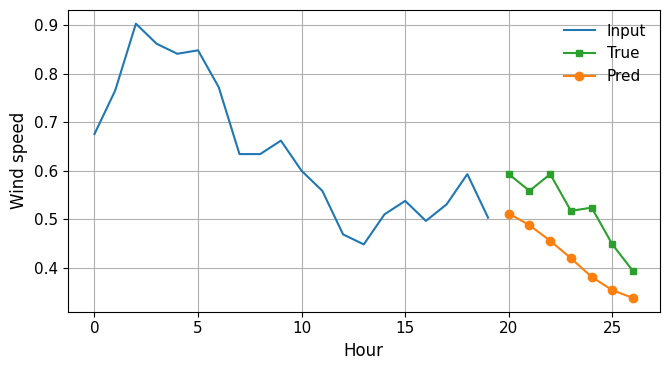

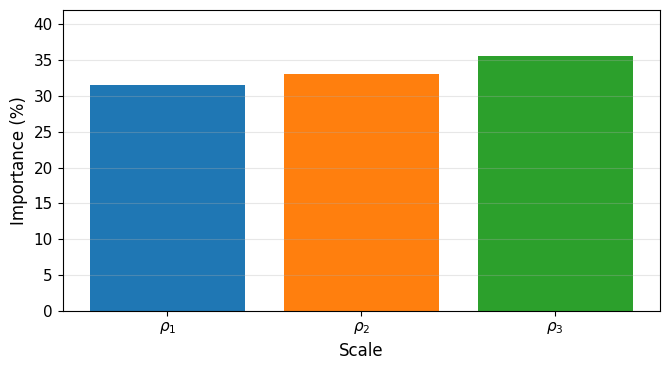

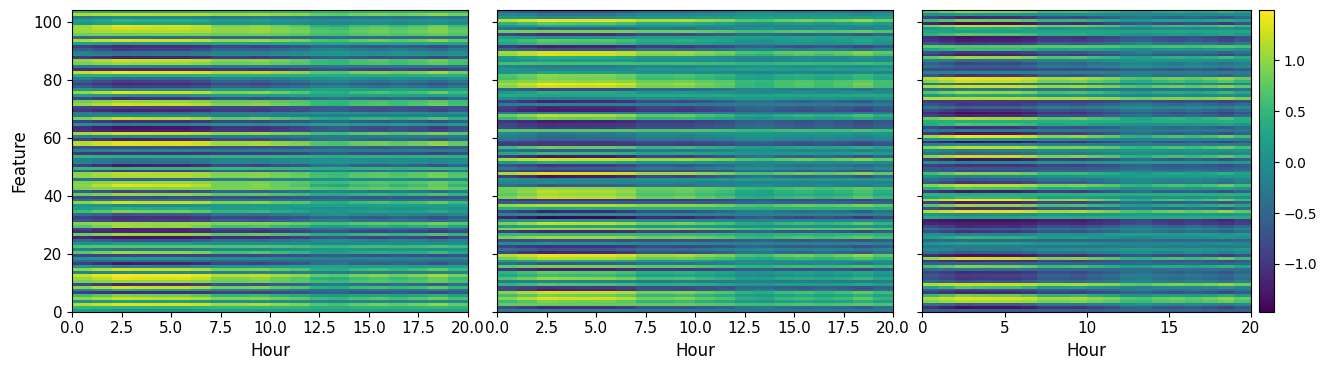

In [15]:
from pathlib import Path


def _bands(s: str) -> tuple[float, ...]:
    return tuple(float(x) for x in s.split("-"))


IND_TAG = "individual"  # etiqueta para indicar plots individuales


_cfg = {
    "Argonne": {
        "RNN": dict(horizon=7, rnn_type="RNN", bands=_bands("6-24-72"), nf_per_band=48, hidden=32, num_layers=3, bidirectional=False, use_tsb=True, kernel="gaussian", spectral_dropout_p=0.2, pool="last"),
        "GRU": dict(horizon=7, rnn_type="GRU", bands=_bands("12-24-168"), nf_per_band=24, hidden=256, num_layers=3, bidirectional=False, use_tsb=True, kernel="gaussian", spectral_dropout_p=0.1, pool="last"),
        "LSTM": dict(horizon=7, rnn_type="LSTM", bands=_bands("12-24-168"), nf_per_band=104, hidden=144, num_layers=3, bidirectional=False, use_tsb=True, kernel="gaussian", spectral_dropout_p=0.2, pool="last"),
    },
    "Synthetic": {
        "RNN": dict(horizon=24, rnn_type="RNN", bands=_bands("4-24-168"), nf_per_band=32, hidden=48, num_layers=1, bidirectional=False, use_tsb=True, kernel="gaussian", spectral_dropout_p=0.5, pool="last"),
        "GRU": dict(horizon=24, rnn_type="GRU", bands=_bands("12-24-168"), nf_per_band=24, hidden=256, num_layers=3, bidirectional=False, use_tsb=True, kernel="gaussian", spectral_dropout_p=0.1, pool="last"),
        "LSTM": dict(horizon=24, rnn_type="LSTM", bands=_bands("4-24-168"), nf_per_band=16, hidden=176, num_layers=1, bidirectional=False, use_tsb=True, kernel="gaussian", spectral_dropout_p=0.3, pool="last"),
    },
}

cfg_per_rnn = _cfg.get(which, _cfg["Argonne"])

rff_plot_dir = Path(ROOT) / "results" / "plots" / "RFFs"
rff_plot_dir.mkdir(parents=True, exist_ok=True)


def _save_fig(fig: "plt.Figure", stem: str) -> None:
    out = rff_plot_dir / f"{IND_TAG}_{stem}.pdf"
    fig.savefig(out, dpi=150, bbox_inches="tight")



FONT_AX = 12
FONT_TICK = 11


def _style_axes(ax: "plt.Axes") -> None:
    ax.tick_params(axis="both", which="major", labelsize=FONT_TICK)
    ax.xaxis.label.set_size(FONT_AX)
    ax.yaxis.label.set_size(FONT_AX)



def _plot_forecast(x_plot: np.ndarray, y_true: np.ndarray, y_pred: np.ndarray, title: str, stem: str) -> None:
    fig, ax = plt.subplots(figsize=(6.8, 3.8))
    ax.plot(x_plot, color="C0", label="Input")
    ax.plot(range(len(x_plot), len(x_plot) + len(y_true)), y_true, "s-", color="C2", markersize=4, label="True")
    ax.plot(range(len(x_plot), len(x_plot) + len(y_pred)), y_pred, "o-", color="C1", label="Pred")
    ax.set_xlabel("Hour")
    ax.set_ylabel("Wind speed")
    #ax.set_title(title, fontsize=FONT_AX)
    ax.grid(True)
    ax.legend(frameon=False, fontsize=FONT_TICK)
    _style_axes(ax)
    plt.tight_layout()
    _save_fig(fig, stem)
    plt.show()



def _plot_rff_bands_row(z0: np.ndarray, z1: np.ndarray, z2: np.ndarray, vmin: float, vmax: float, title: str, stem: str) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), sharey=True)
    bands = [(z0, "Scale 1"), (z1, "Scale 2"), (z2, "Scale 3")]
    im = None
    for i, (ax, (z_band, t)) in enumerate(zip(axes, bands)):
        im = ax.pcolormesh(z_band.T, cmap="viridis", vmin=vmin, vmax=vmax, shading="auto")
        ax.set_xlabel("Hour")
        ax.set_aspect("auto")
        _style_axes(ax)

    axes[0].set_ylabel("Feature")

    # Colorbar a la derecha del subplot derecho
    fig.colorbar(im, ax=axes[2], pad=0.02)

    plt.tight_layout()
    _save_fig(fig, stem)
    plt.show()


x_plot = x_one.cpu().numpy().squeeze()
plotted = False

for rnn_type in ["RNN", "GRU", "LSTM"]:
    path_rnn = Path(ROOT) / "results" / "models" / f"best_model_{which}_{rnn_type}.pth"
    if not path_rnn.exists():
        continue

    args = cfg_per_rnn[rnn_type]
    m = RFF_AnyRNN_Forecaster(**args).to(device)
    _ = m(torch.zeros(1, x_one.shape[1], 1, device=device))
    m.load_state_dict(torch.load(path_rnn, map_location=device))
    m.eval()

    with torch.no_grad():
        z = m.enc(x_one).cpu().numpy().squeeze()
        pred = m(x_one).cpu().numpy().squeeze()

    nf = z.shape[1] // 3
    z0, z1, z2 = z[:, :nf], z[:, nf : 2 * nf], z[:, 2 * nf :]
    vmin = float(min(z0.min(), z1.min(), z2.min()))
    vmax = float(max(z0.max(), z1.max(), z2.max()))

    _plot_forecast(
        x_plot=x_plot,
        y_true=y_true_one,
        y_pred=pred,
        title=f"{which} · {rnn_type} · Forecast",
        stem=f"{which}_{rnn_type}_forecast",
    )
    _plot_rff_bands_row(
        z0,
        z1,
        z2,
        vmin,
        vmax,
        #title=f"{which} · {rnn_type} · RFF bands",
        stem=f"{which}_{rnn_type}_rff_bands",
    )

    plotted = True

if not plotted:
    nf_per_band = z_rff.shape[1] // 3
    z_band0 = z_rff[:, :nf_per_band]
    z_band1 = z_rff[:, nf_per_band : 2 * nf_per_band]
    z_band2 = z_rff[:, 2 * nf_per_band :]
    vmin = float(min(z_band0.min(), z_band1.min(), z_band2.min()))
    vmax = float(max(z_band0.max(), z_band1.max(), z_band2.max()))

    # Integrated Gradients per band for this input and model
    model.eval()
    z_input = model.enc(x_one).detach()
    baseline = torch.zeros_like(z_input)
    steps = 64
    acc_grad = torch.zeros_like(z_input)
    for alpha in torch.linspace(0.0, 1.0, steps, device=z_input.device):
        z_alpha = baseline + alpha * (z_input - baseline)
        z_alpha.requires_grad_(True)
        h = model.tsb(z_alpha)
        H, _ = model.rnn(h)
        y = model.head(H)
        target = y.mean()
        grad = torch.autograd.grad(target, z_alpha, retain_graph=False, create_graph=False)[0]
        acc_grad += grad
    avg_grad = acc_grad / steps
    ig = (z_input - baseline) * avg_grad

    nf = ig.shape[-1] // 3
    ig_abs = ig.abs()[0]
    imp = np.array(
        [
            ig_abs[:, :nf].sum().item(),
            ig_abs[:, nf : 2 * nf].sum().item(),
            ig_abs[:, 2 * nf :].sum().item(),
        ],
        dtype=np.float64,
    )
    imp_pct = 100.0 * imp / imp.sum()

    _plot_forecast(
        x_plot=x_plot,
        y_true=y_true_one,
        y_pred=y_pred_one,
        title=f"{which} · Forecast",
        stem=f"{which}_forecast",
    )

    fig, ax = plt.subplots(figsize=(6.8, 3.8))
    ax.bar([0, 1, 2], imp_pct, color=["C0", "C1", "C2"])
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([r"$\rho_1$", r"$\rho_2$", r"$\rho_3$"])
    ax.set_xlabel("Scale")
    ax.set_ylabel("Importance (%)")
    #ax.set_ylim(0, 100)
    ax.set_ylim(0, 42)
    ax.grid(True, axis="y", alpha=0.3)
    _style_axes(ax)
    plt.tight_layout()
    _save_fig(fig, f"{which}_ig_importance")
    plt.show()

    _plot_rff_bands_row(
        z_band0,
        z_band1,
        z_band2,
        vmin,
        vmax,
        title=f"{which} · RFF bands",
        stem=f"{which}_rff_bands",
    )
